In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("data.csv", delimiter='\t', low_memory=False)
df.head()

,Unnamed: 0,date,id,size_grp,age,aliq_at,aliq_mat,ami_126d,at_be,at_gr1,...,turnover_var_126d,z_score,zero_trades_126d,zero_trades_21d,zero_trades_252d,ret,Unnamed: 126,Unnamed: 127,Unnamed: 128,Unnamed: 129
0,53170,9/30/1962,33814,mega,-0.4108911,0.3436155,0.0,-0.290922,-0.44744524,0.24796748,...,0.27476254,0.0,0.17842606,0.033875,0.0,0.017612524,NaN,NaN,NaN,NaN
1,53907,10/31/1962,33814,mega,-0.41374046,0.33333334,0.0,-0.281893,-0.44759825,0.23134328,...,0.21059783,0.0,0.13586956,0.094301,0.0,0.1242307722568512,NaN,NaN,NaN,NaN
2,54659,11/30/1962,33814,mega,-0.4017857,0.33169705,0.0,-0.297587,-0.4487909,0.2214854,...,0.1679947,0.0,0.1374502,0.111406,0.0,-0.01208981,NaN,NaN,NaN,NaN
3,55425,12/31/1962,33814,mega,-0.37068966,0.32225236,0.0,-0.309585,-0.4398085,0.21501926,...,0.12516046,0.0,0.1097561,0.194480,0.11369509,0.087412588,NaN,NaN,NaN,NaN
4,56207,1/31/1963,33814,mega,-0.36795145,0.32456142,0.0,-0.308729,-0.44189188,0.21082802,...,0.035714287,0.0,0.10841837,0.149682,0.08151476,-0.021864953,NaN,NaN,NaN,NaN


In [4]:
df.drop(columns=['Unnamed: 126', 'Unnamed: 127', 'Unnamed: 128', 'Unnamed: 129'], inplace=True)
df = df.iloc[:-2, :]
df = df.drop(index=range(122974, 122978))
df.drop(columns=['size_grp'], inplace=True)
df.dropna(inplace=True)
date = df['date']
print(date.shape)
df.drop(columns=['date'], inplace=True)

(122634,)


In [5]:
df.dropna(inplace=True)
print(df.shape)

(122634, 124)


In [6]:
df.to_csv("cleaned_data.csv", index=False)
date.to_csv("cleaned_date.csv", index=False)

Ridge Regression MSE (alpha=1.0): 0.0104


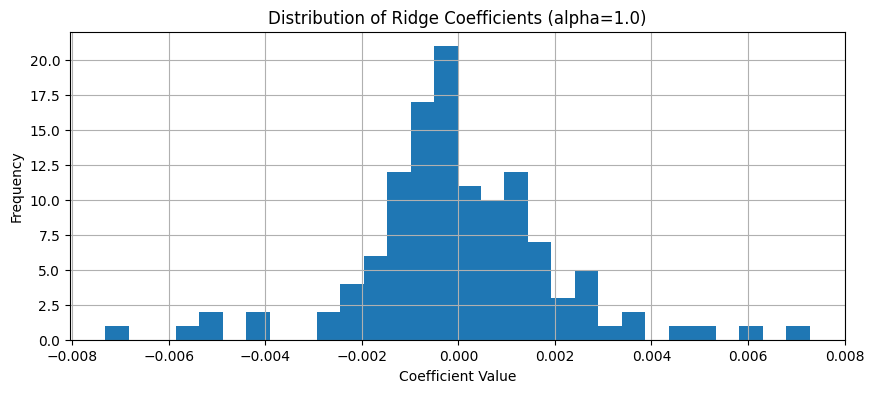

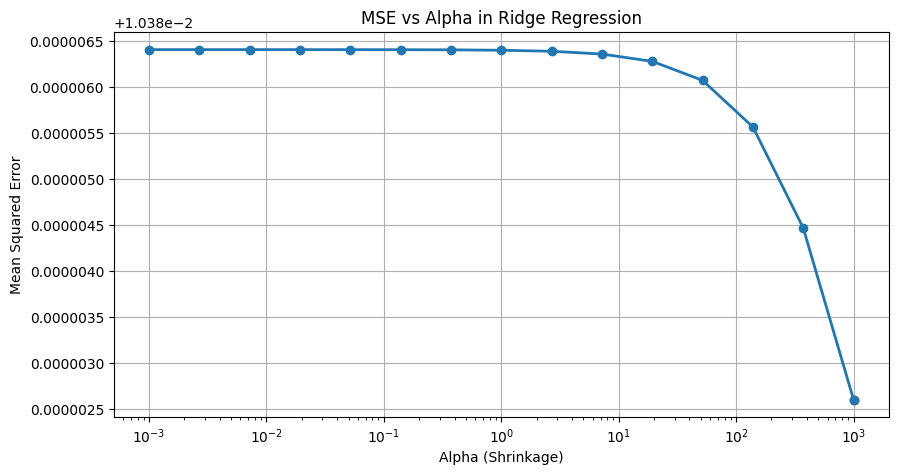

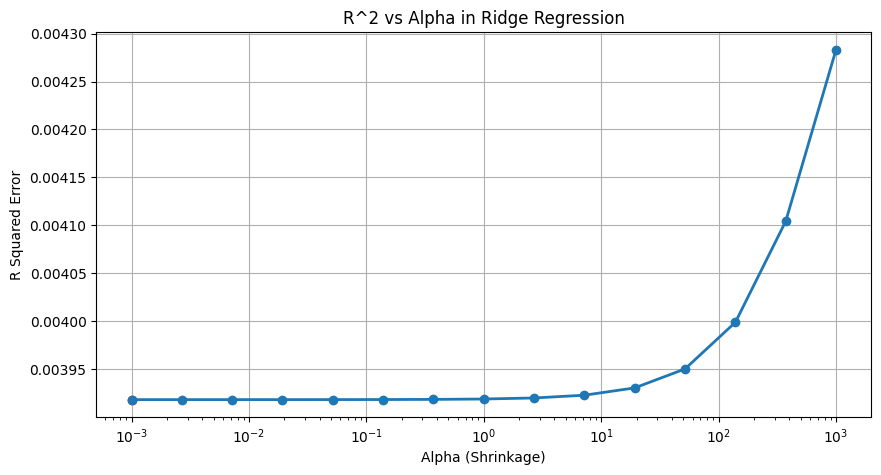

In [7]:
X_unscaled = df.drop(columns='ret')
X_unscaled = X_unscaled.apply(pd.to_numeric, errors='coerce')
X = (X_unscaled-X_unscaled.mean(axis=0))/X_unscaled.std(axis=0)

y = df['ret']
y = y.apply(pd.to_numeric, errors='coerce')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge regression with alpha=1.0
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

# Compute and print MSE
mse = mean_squared_error(y_test, y_pred)
print(f"Ridge Regression MSE (alpha=1.0): {mse:.4f}")

# Plot distribution of coefficients
plt.figure(figsize=(10, 4))
plt.hist(ridge.coef_, bins=30)
plt.title("Distribution of Ridge Coefficients (alpha=1.0)")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Analyze effect of varying alpha
alphas = np.logspace(-3, 3, 15)
coefs = []
mses = []
rs = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    coefs.append(model.coef_)
    y_pred = model.predict(X_test)
    mses.append(mean_squared_error(y_test, y_pred))
    rs.append(r2_score(y_test, y_pred))


best_idx_ms = np.argmin(mses)
best_idx_rs = np.argmin(rs)

best_alpha_ms = alphas[best_idx_ms]
best_mse = mses[best_idx_ms]

best_alpha_rs = alphas[best_idx_rs]
best_rs = rs[best_idx_rs]

def plot(losses, best_loss, name_loss, abbrev, best_alpha, alphas):
    plt.figure(figsize=(10, 5))
    plt.plot(alphas, losses, marker='o', linewidth=2)
    plt.xscale("log")
    plt.xlabel("Alpha (Shrinkage)")
    plt.ylabel(name_loss)
    plt.title(abbrev + " vs Alpha in Ridge Regression")
    plt.grid(True)

    # Turn off scientific notation
    plt.ticklabel_format(style='plain', axis='y')
    
    # Annotate best point
    plt.scatter(best_alpha, best_loss, color='red')
    
    plt.show()


plot(mses, best_mse, 'Mean Squared Error', 'MSE', best_alpha_ms, alphas)
plot(rs, best_rs, 'R Squared Error', 'R^2', best_alpha_rs, alphas)



**Let us now do it mathematically to check Sklearn isn't playing any tricks on us !**

In [8]:
y.dtypes

dtype('float64')

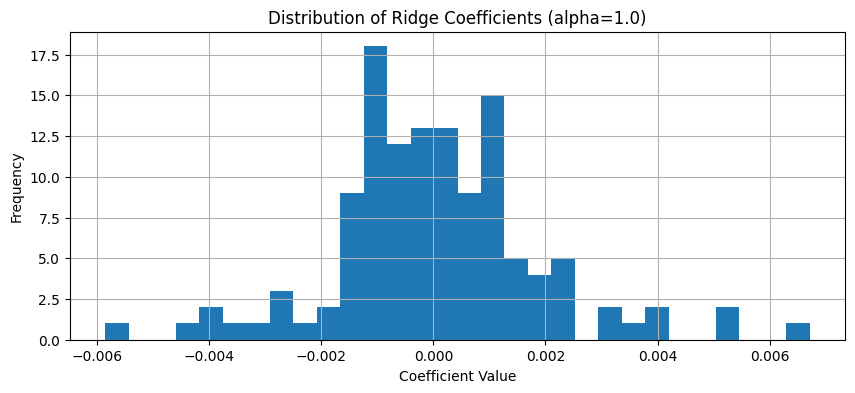

In [9]:
def ridge_reg(X, y, alpha, use_trick=False):
    if use_trick:
        # Inversion trick (better for tall matrices)
        n_samples = X.shape[0]
        A = np.matmul(X, X.T) + alpha * np.identity(n_samples)
        A_inv = np.linalg.pinv(A)
        w = np.matmul(X.T, np.matmul(A_inv, y))
    else:
        # Standard ridge formula
        n_features = X.shape[1]
        A = np.matmul(X.T, X) + alpha * np.identity(n_features)
        A_inv = np.linalg.pinv(A)
        w = np.matmul(A_inv, np.matmul(X.T, y))
    return w

w = ridge_reg(X, y, 1.0)

# Plot distribution of coefficients
plt.figure(figsize=(10, 4))
plt.hist(w, bins=30)
plt.title("Distribution of Ridge Coefficients (alpha=1.0)")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

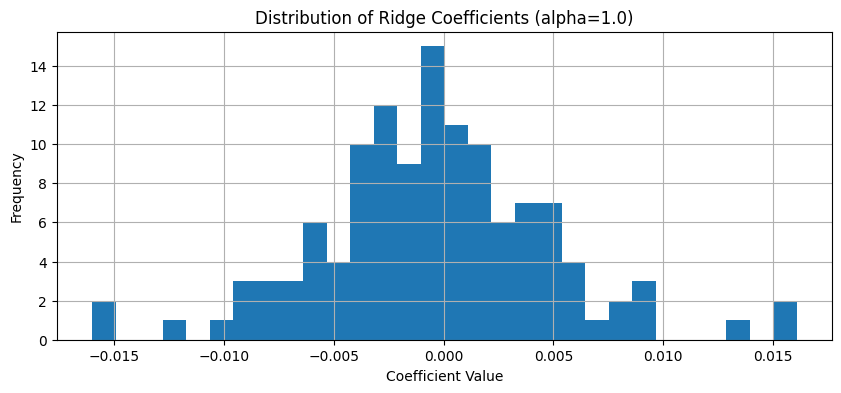

In [10]:
w = ridge_reg(X_unscaled, y, 1.0)

# Plot distribution of coefficients
plt.figure(figsize=(10, 4))
plt.hist(w, bins=30)
plt.title("Distribution of Ridge Coefficients (alpha=1.0)")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

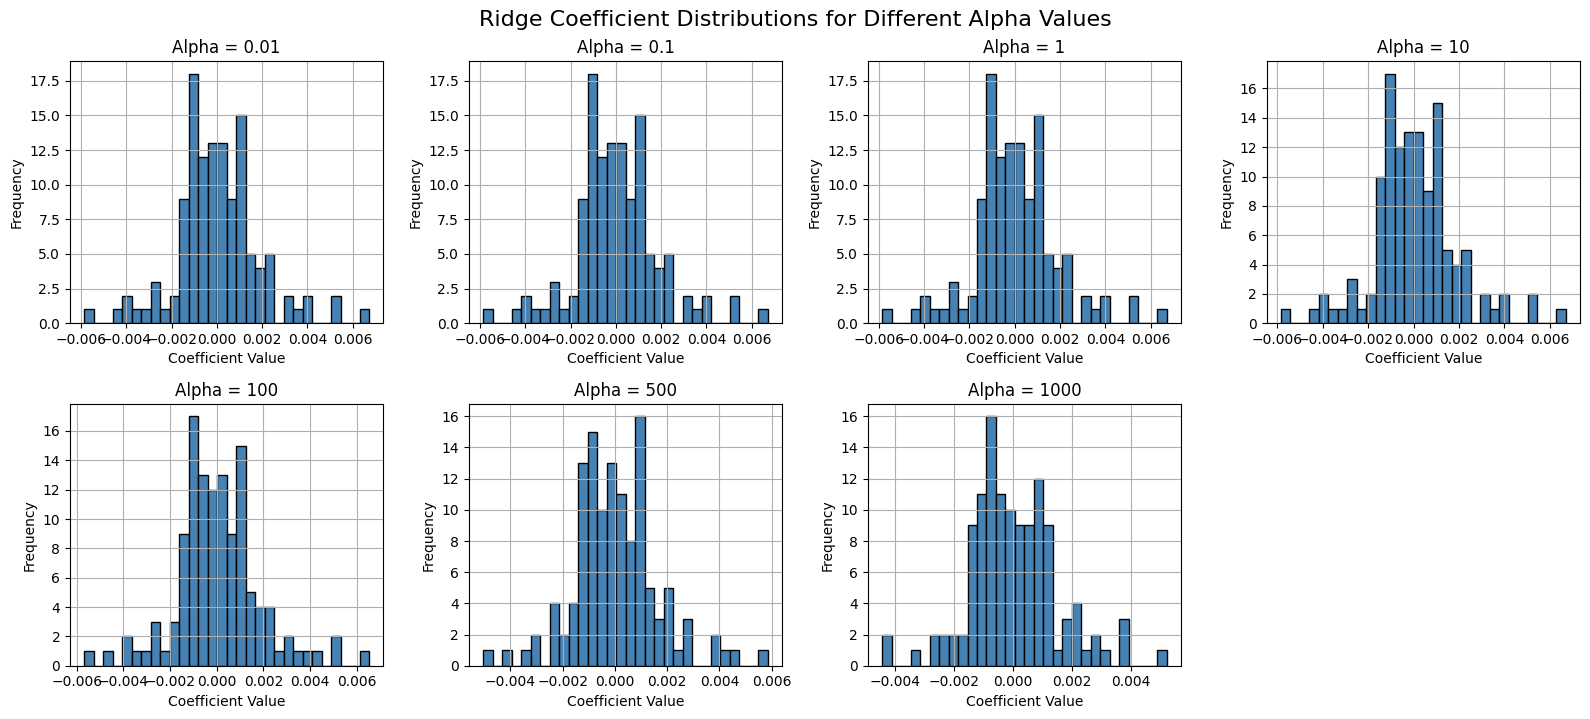

In [11]:
import numpy as np
import matplotlib.pyplot as plt


# Define a range of alphas
alphas = [0.01, 0.1, 1, 10, 100, 500, 1000]

# Store coefficients
weights = []

for alpha in alphas:
    w = ridge_reg(X, y, alpha)
    weights.append(w)

# Plot: Distributions of coefficients
n_cols = 4
n_rows = int(np.ceil(len(alphas) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))

for i, (alpha, w) in enumerate(zip(alphas, weights)):
    ax = axes.flat[i]
    ax.hist(w, bins=30, color='steelblue', edgecolor='black')
    ax.set_title(f'Alpha = {alpha}')
    ax.set_xlabel('Coefficient Value')
    ax.set_ylabel('Frequency')
    ax.grid(True)

# Hide unused subplots (if any)
for j in range(i+1, n_rows * n_cols):
    fig.delaxes(axes.flat[j])

plt.tight_layout()
plt.suptitle("Ridge Coefficient Distributions for Different Alpha Values", fontsize=16, y=1.02)
plt.show()


In [12]:
import time

alpha = 1.0
X_sampled, y_sampled = X.sample(n=40, random_state=42), y.loc[X.sample(n=40, random_state=42).index]


# Time standard method
start_std = time.time()
w_std = ridge_reg(X_sampled, y_sampled, alpha, use_trick=False)
end_std = time.time()

# Time inversion trick
start_trick = time.time()
w_trick = ridge_reg(X_sampled, y_sampled, alpha, use_trick=True)
end_trick = time.time()

print(f"Standard method took: {(end_std - start_std) * 1000:.2f} ms")
print(f"Inversion trick took: {(end_trick - start_trick) * 1000:.2f} ms")


Standard method took: 39.97 ms
Inversion trick took: 4.12 ms


In [13]:
import time

alpha = 1.0
X_sampled, y_sampled = X.sample(n=500, random_state=42), y.loc[X.sample(n=500, random_state=42).index]


# Time standard method
start_std = time.time()
w_std = ridge_reg(X_sampled, y_sampled, alpha, use_trick=False)
end_std = time.time()

# Time inversion trick
start_trick = time.time()
w_trick = ridge_reg(X_sampled, y_sampled, alpha, use_trick=True)
end_trick = time.time()

print(f"Standard method took: {(end_std - start_std) * 1000:.2f} ms")
print(f"Inversion trick took: {(end_trick - start_trick) * 1000:.2f} ms")


Standard method took: 90.11 ms
Inversion trick took: 291.20 ms


In [14]:
date = pd.to_datetime(date, errors='coerce')

In [15]:
date.head()

0   1962-09-30
1   1962-10-31
2   1962-11-30
3   1962-12-31
4   1963-01-31
Name: date, dtype: datetime64[ns]

In [16]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

# Drop duplicates and extract features
df_uni = df.drop_duplicates(subset='id')
X = df_uni.drop(columns=['ret'])
y = df_uni['ret']

X_train, X_test, y_train, y_test = train_test_split(
    X , y, 
    test_size=0.7,
    random_state=42,
    shuffle=True
)

X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')
y_train = y_train.apply(pd.to_numeric, errors='coerce')
y_test = y_test.apply(pd.to_numeric, errors='coerce')

alpha = 1.0
w = ridge_reg(X_train, y_train, alpha)

y_pred = X_test @ w

managed_returns = y_pred * y_test.values

# Performance evaluation
avg_return = managed_returns.mean()
sharpe_ratio = managed_returns.mean() / managed_returns.std()

print(f"Mean return: {avg_return:.4f}")
print(f"Sharpe ratio: {sharpe_ratio:.4f}")


Mean return: 0.0006
Sharpe ratio: 0.0368


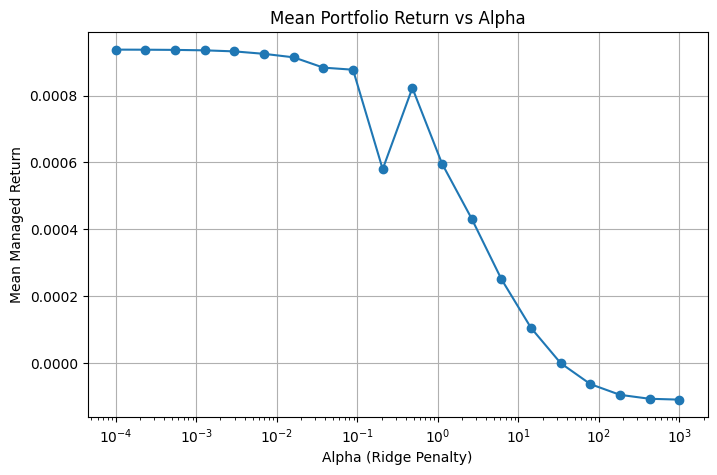

In [17]:
# Range of alphas
alphas = np.logspace(-4, 3, 20)
avg_returns = []

for alpha in alphas:
    w = ridge_reg(X_train, y_train, alpha)
    y_pred = X_test @ w
    managed_returns = y_pred * y_test.values
    avg_return = managed_returns.mean()
    avg_returns.append(avg_return)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(alphas, avg_returns, marker='o')
plt.xscale('log')
plt.xlabel("Alpha (Ridge Penalty)")
plt.ylabel("Mean Managed Return")
plt.title("Mean Portfolio Return vs Alpha")
plt.grid(True)
plt.show()

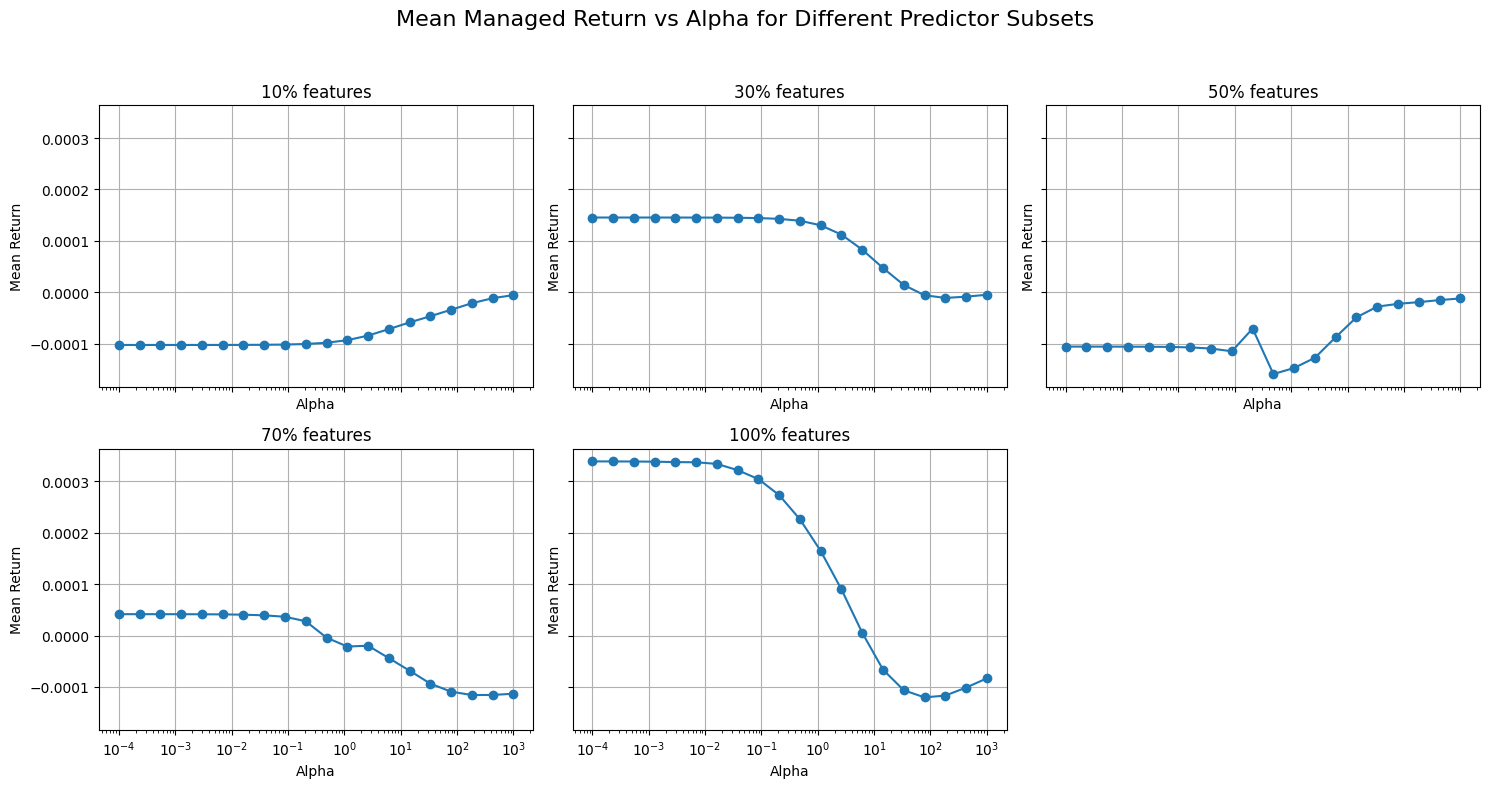

In [18]:
# Let's test how using fewer predictors affects managed return vs alpha

def ridge_alphas_predictors(X_train, X_test, y_train, y_test):
    subset_ratios = [0.1, 0.3, 0.5, 0.7, 1.0]  # Fractions of total features
    alphas = np.logspace(-4, 3, 20)
    results = {}
    
    for ratio in subset_ratios:
        num_features = int(X_train.shape[1] * ratio)
        selected_columns = np.random.choice(X_train.shape[1], num_features)
    
        avg_returns = []
        for alpha in alphas:
            use_trick = num_features > X_train.shape[0]
            w = ridge_reg(X_train.iloc[:, selected_columns].values, y_train.values, alpha, use_trick=use_trick)
            y_pred = X_test.iloc[:, selected_columns].values @ w
            managed_returns = y_pred * y_test.values
            avg_return = managed_returns.mean()
            avg_returns.append(avg_return)
    
        results[f"{int(ratio * 100)}% features"] = avg_returns
    
    # Plot the previous "Mean Return vs Alpha" curves in subplots like the example image
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    
    for i, (label, avg_returns) in enumerate(results.items()):
        axes[i].plot(alphas, avg_returns, marker='o')
        axes[i].set_title(label)
        axes[i].set_xscale('log')
        axes[i].set_xlabel("Alpha")
        axes[i].set_ylabel("Mean Return")
        axes[i].grid(True)
    
    # Hide unused subplot if subset count < total axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle("Mean Managed Return vs Alpha for Different Predictor Subsets", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


ridge_alphas_predictors(X_train, X_test, y_train, y_test)

In [19]:
import pandas as pd

df.columns = df.columns.str.strip().str.lower()  # clean all column names

vol_df = df.groupby('id')['ret'].std().rename('volatility').reset_index()
df = df.merge(vol_df, on='id')

df = df.apply(pd.to_numeric, errors='coerce')

print(df.dtypes)
median_vol = df['volatility'].median()
df_low_vol = df[df['volatility'] <= median_vol].copy()
df_high_vol = df[df['volatility'] > median_vol].copy()

X_train_high, X_test_high, y_train_high, y_test_high = train_test_split(
    df_high_vol.drop(columns=['ret']) , df_high_vol['ret'], 
    test_size=0.7,
    random_state=42,
    shuffle=True
)

X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(
    df_low_vol.drop(columns=['ret']) , df_low_vol['ret'], 
    test_size=0.7,
    random_state=42,
    shuffle=True
)

unnamed: 0            int64
id                    int64
age                 float64
aliq_at             float64
aliq_mat            float64
                     ...   
zero_trades_126d    float64
zero_trades_21d     float64
zero_trades_252d    float64
ret                 float64
volatility          float64
Length: 125, dtype: object


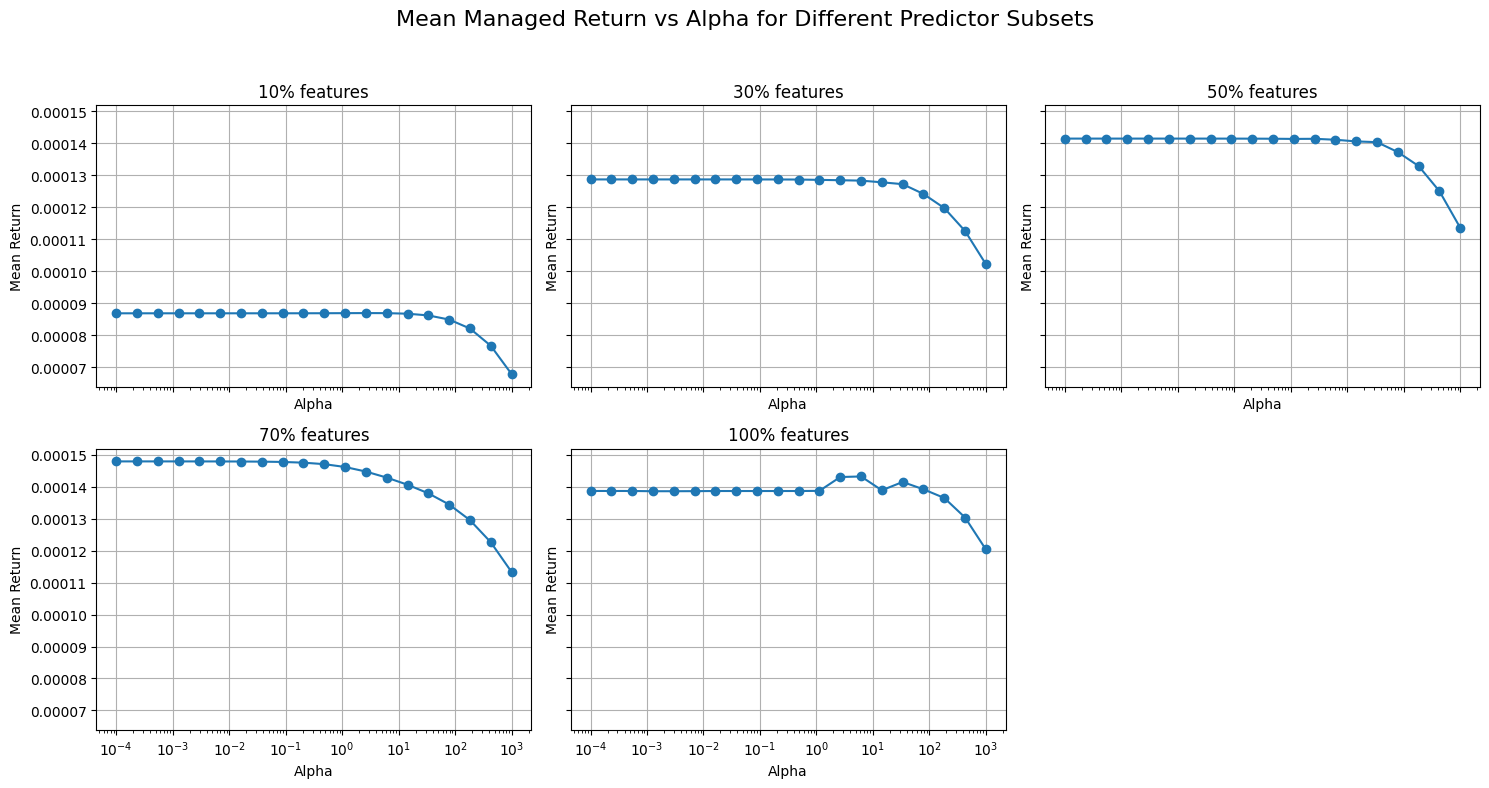

In [20]:
ridge_alphas_predictors(X_train_high, X_test_high, y_train_high, y_test_high)

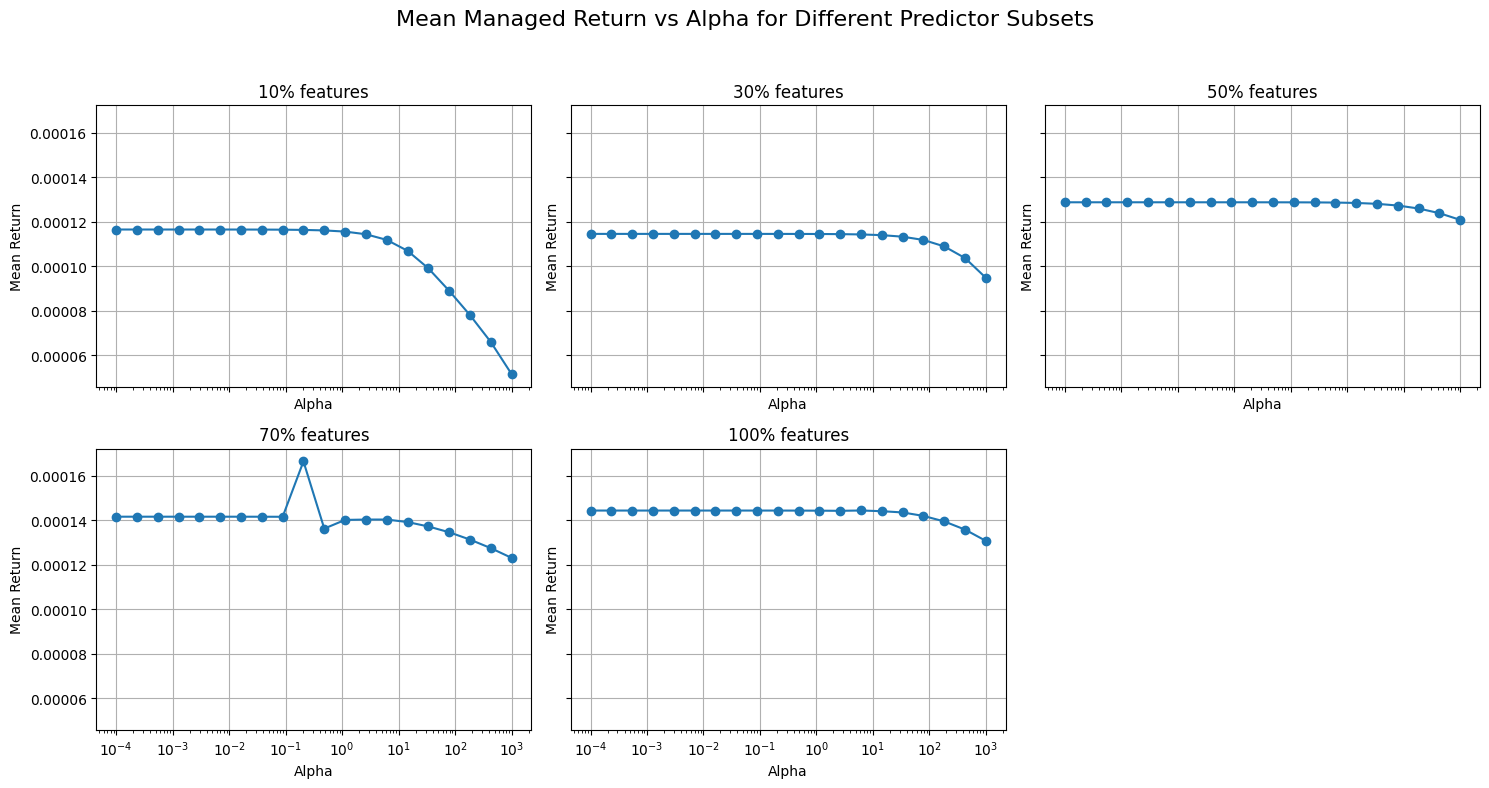

In [21]:
ridge_alphas_predictors(X_train_low, X_test_low, y_train_low, y_test_low)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Function for rolling window CV
def rolling_ridge_cv(X, y, alphas, window_size=100, overlap=False):


    test_size = int(window_size * 0.3)
    n = X.shape[0]
    y = y[:n]
    step = 1 if overlap else test_size
    alpha_results = []
    y_preds = []
    y_tests = []
    scores = []


    for start in range(0, n - n%(window_size + step) - 1, window_size + step):
        
        X_train = X.iloc[start:start + window_size]
        y_train = y.iloc[start:start + window_size]
        X_test = X.iloc[start + window_size:start + window_size + step]
        y_test = y.iloc[start + window_size:start + window_size + step]

        best_alpha = None
        best_score = float('inf')
        mini_y_pred = []
        mini_score = []
        mini_y_test = []

        for alpha in alphas:
            model = Ridge(alpha=1.0)
            try:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                mini_y_pred.append(y_pred)
                score = mean_squared_error(y_test, y_pred)
                mini_y_test.append(y_test)
                mini_score.append(score)

                if score < best_score:
                    best_score = score
                    best_alpha = alpha

            except Exception as e:
                print(f"\n⚠️ Error during fit at iteration starting at index {start}")
                print(f"Alpha: {alpha}")
                print(f"X_train shape: {X_train.shape}")
                print(f"y_train shape: {y_train.shape}")
                print(f"X_test shape: {X_test.shape}")
                print(f"y_test shape: {y_test.shape}")
                print("Exception message:", str(e))
                continue  
            
        alpha_results.append(best_alpha)
        if start%(20*(window_size+step)) == 0 : print(start)

        y_preds.append(mini_y_pred)
        scores.append(mini_score)
        y_tests.append(mini_y_test)


    return alpha_results, y_tests, y_preds, scores

alphas = np.logspace(-3, 3, 15)

X = df.drop(columns=['ret']) 
X.dropna(inplace=True)
y =  df['ret'] 

print(X.head())
print(y.head())

print(X.shape)
print(y.shape)

# Run both non-overlapping and overlapping CV



   unnamed: 0     id       age   aliq_at  aliq_mat  ami_126d     at_be  \
0       53170  33814 -0.410891  0.343616       0.0 -0.290922 -0.447445   
1       53907  33814 -0.413740  0.333333       0.0 -0.281893 -0.447598   
2       54659  33814 -0.401786  0.331697       0.0 -0.297587 -0.448791   
3       55425  33814 -0.370690  0.322252       0.0 -0.309585 -0.439808   
4       56207  33814 -0.367951  0.324561       0.0 -0.308729 -0.441892   

     at_gr1  at_me  at_turnover  ...  taccruals_ni  tangibility  tax_gr1a  \
0  0.247967   -0.5    -0.272358  ...     -0.219101     0.398990 -0.008820   
1  0.231343   -0.5    -0.272049  ...     -0.217949     0.397250 -0.023098   
2  0.221485   -0.5    -0.277188  ...     -0.217868     0.399718 -0.027224   
3  0.215019   -0.5    -0.274069  ...     -0.224242     0.398491 -0.032134   
4  0.210828   -0.5    -0.274522  ...     -0.231928     0.399183 -0.044643   

   turnover_126d  turnover_var_126d  z_score  zero_trades_126d  \
0      -0.379240          

In [93]:
X.shape

(122575, 124)

In [114]:
alphas_non_overlap, y_tests_no, y_preds_no, scores_no = rolling_ridge_cv(X, y, alphas, window_size=100, overlap=False)


0
2600
5200
7800
10400
13000
15600
18200
20800
23400
26000
28600
31200
33800
36400
39000
41600
44200
46800
49400
52000
54600
57200
59800
62400
65000
67600
70200
72800
75400
78000
80600
83200
85800
88400
91000
93600
96200
98800
101400
104000
106600
109200
111800
114400
117000
119600
122200


In [115]:
alphas_overlap, y_tests_o, y_preds_o, scores_o = rolling_ridge_cv(X, y, alphas, window_size=100, overlap=True)


0
2020
4040
6060
8080
10100
12120
14140
16160
18180
20200
22220
24240
26260
28280
30300
32320
34340
36360
38380
40400
42420
44440
46460
48480
50500
52520
54540
56560
58580
60600
62620
64640
66660
68680
70700
72720
74740
76760
78780
80800
82820
84840
86860
88880
90900
92920
94940
96960
98980
101000
103020
105040
107060
109080
111100
113120
115140
117160
119180
121200


In [116]:
def av_window(y_preds, y_tests, overlap=False):
    avg_preds = [np.mean(np.ravel(pred)) for pred in y_preds]
    avg_truth = [np.mean(np.ravel(true)) for true in y_tests]

    plt.figure(figsize=(10, 4))
    plt.plot(avg_truth, label="True Mean Return", marker='o')
    plt.plot(avg_preds, label="Predicted Mean Return", marker='x')
    plt.xlabel("Rolling Window Index")
    plt.ylabel("Average Return")
    txt = "without" if not overlap else "with"
    plt.title("Per-Window Mean: True vs Predicted "+txt+" overlap")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



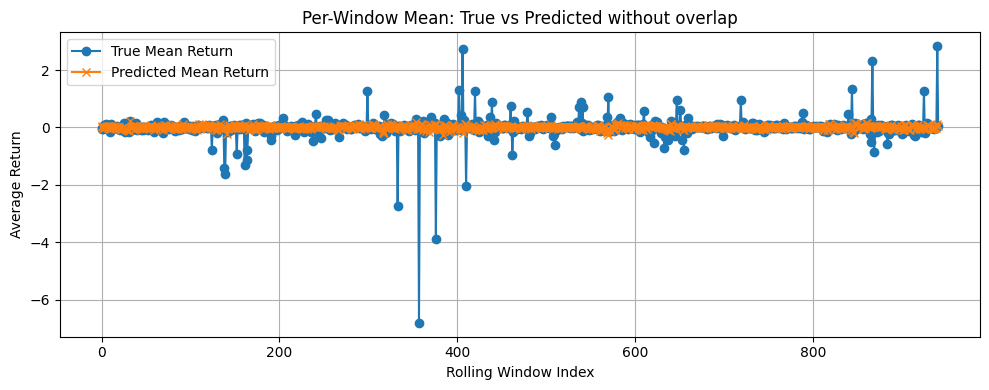

In [117]:
av_window(y_preds_no, y_tests_no, overlap=False)

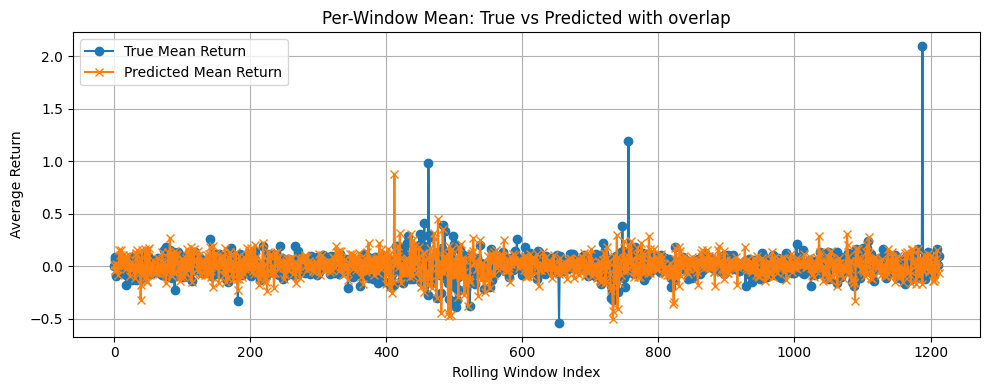

In [118]:
av_window(y_preds_o, y_tests_o, overlap=True)

In [122]:
def mse_window(y_preds, y_tests, overlap=False):

    mse_per_window = [
        mean_squared_error(np.ravel(y_true), np.ravel(y_pred))
        for y_true, y_pred in zip(y_tests, y_preds)
    ]

    plt.figure(figsize=(10, 4))
    plt.plot(mse_per_window, label="Per-Window MSE", color='red', marker='s')
    plt.xlabel("Rolling Window Index")
    plt.ylabel("MSE")
    txt = "without" if not overlap else "with"
    plt.title("Prediction Error per Rolling Window "+txt+" overlap")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

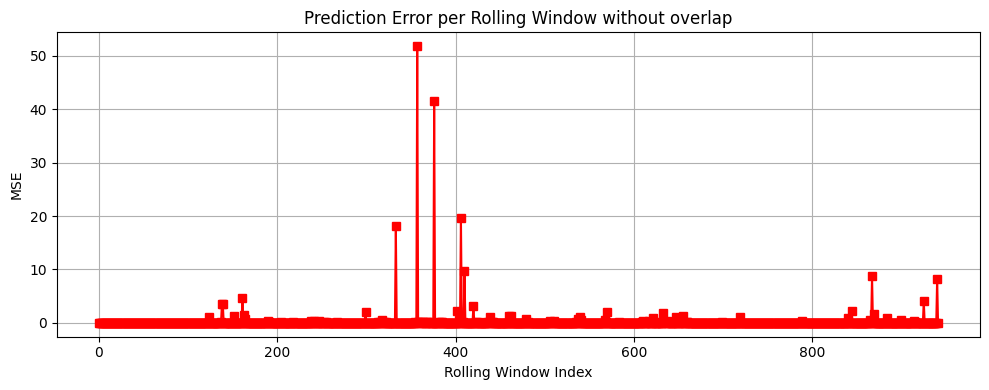

In [123]:
mse_window(y_preds_no, y_tests_no, overlap=False)

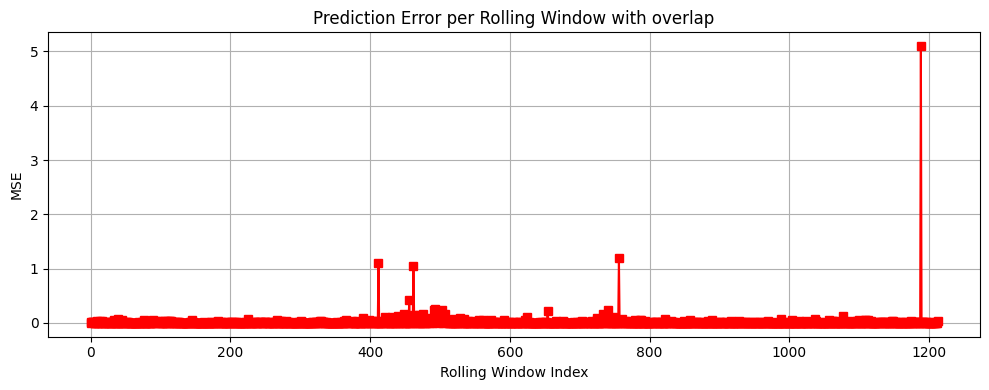

In [124]:
mse_window(y_preds_o, y_tests_o, overlap=True)

In [125]:
def bias_window(y_preds, y_tests, overlap=False):

    bias_per_window = [
        np.mean(np.ravel(y_pred) - np.ravel(y_true))
        for y_true, y_pred in zip(y_tests, y_preds)
    ]

    plt.figure(figsize=(10, 4))
    plt.plot(bias_per_window, label="Prediction Bias (Pred - True)", color='purple')
    plt.axhline(0, linestyle='--', color='black', linewidth=1)
    plt.xlabel("Rolling Window Index")
    plt.ylabel("Prediction Bias")
    txt = "without" if not overlap else "with"
    plt.title("Rolling Prediction Bias (Avg Error) "+txt+" overlap")
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()


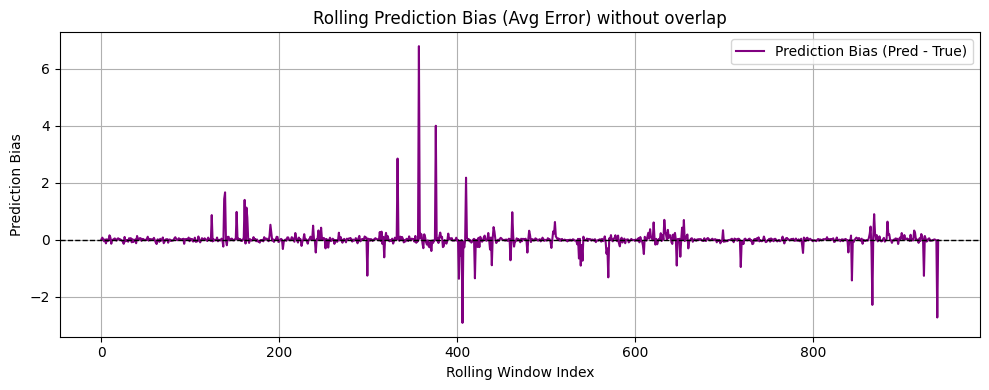

In [126]:
bias_window(y_preds_no, y_tests_no, overlap=False)

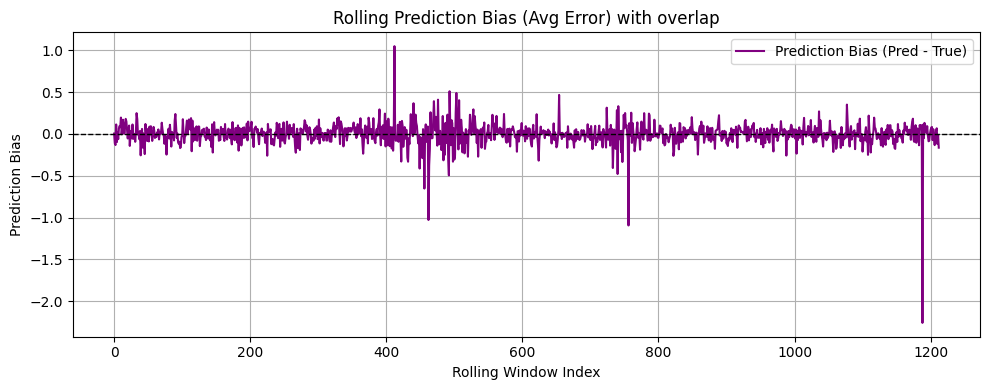

In [127]:
bias_window(y_preds_o, y_tests_o, overlap=True)

In [128]:
def plot_alpha_evolution(alphas, overlap=False):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 4))
    plt.plot(alphas, marker='o', label="Selected Alpha")
    plt.yscale('log')
    plt.xlabel("Rolling Window Index")
    plt.ylabel("Alpha (Regularization Strength)")
    txt = "without" if not overlap else "with"
    plt.title("Alpha Evolution per Rolling Window " + txt + " overlap")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


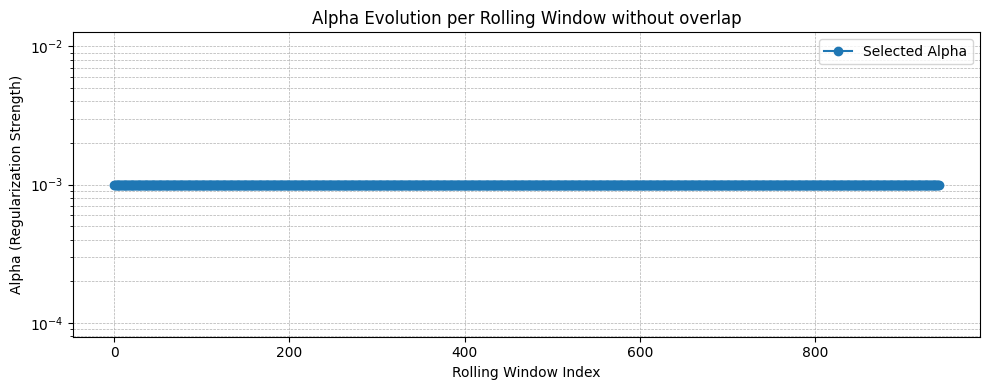

In [129]:
plot_alpha_evolution(alphas_non_overlap, overlap=False)


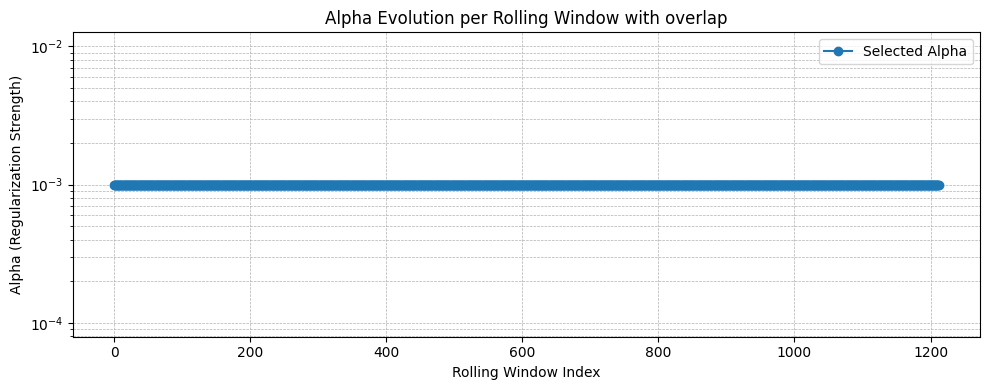

In [ ]:
plot_alpha_evolution(alphas_overlap, overlap=True) 


In [131]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def nested_cv_ridge(X, y, alphas, outer_splits=5, inner_splits=3, random_state=42):
    outer_cv = KFold(n_splits=outer_splits, shuffle=True, random_state=random_state)
    all_outer_scores = []
    selected_alphas = []

    for train_idx, test_idx in outer_cv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Inner CV to select best alpha
        inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=random_state)
        inner_scores = []

        for alpha in alphas:
            fold_scores = []
            for inner_train_idx, val_idx in inner_cv.split(X_train):
                X_inner_train, X_val = X_train.iloc[inner_train_idx], X_train.iloc[val_idx]
                y_inner_train, y_val = y_train.iloc[inner_train_idx], y_train.iloc[val_idx]

                model = Ridge(alpha=alpha)
                model.fit(X_inner_train, y_inner_train)
                y_pred = model.predict(X_val)
                score = mean_squared_error(y_val, y_pred)
                fold_scores.append(score)

            avg_score = np.mean(fold_scores)
            inner_scores.append((alpha, avg_score))

        # Select best alpha from inner CV
        best_alpha = min(inner_scores, key=lambda x: x[1])[0]
        selected_alphas.append(best_alpha)

        # Retrain on full training set with best alpha
        final_model = Ridge(alpha=best_alpha)
        final_model.fit(X_train, y_train)
        y_final_pred = final_model.predict(X_test)
        outer_score = mean_squared_error(y_test, y_final_pred)
        all_outer_scores.append(outer_score)

    return selected_alphas, all_outer_scores


In [132]:
alphas_grid = np.logspace(-4, 2, 20)
best_alphas, outer_mse_scores = nested_cv_ridge(X, y, alphas_grid)

print("Selected alphas per fold:", best_alphas)
print("Outer CV MSEs:", outer_mse_scores)
print("Avg MSE:", np.mean(outer_mse_scores))


Selected alphas per fold: [100.0, 100.0, 100.0, 100.0, 100.0]
Outer CV MSEs: [0.010143764292819931, 0.010463959982823607, 0.010168408465688962, 0.009900119446905725, 0.009637917084819312]
Avg MSE: 0.010062833854611508


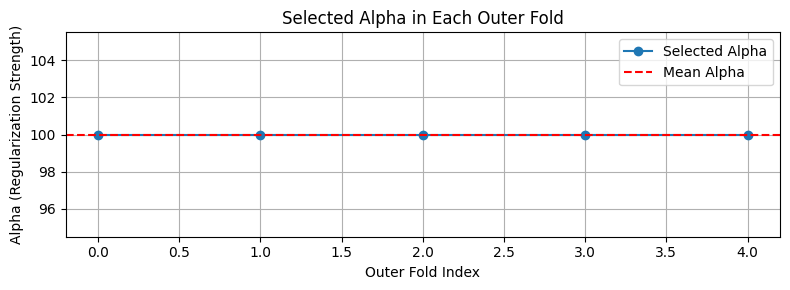

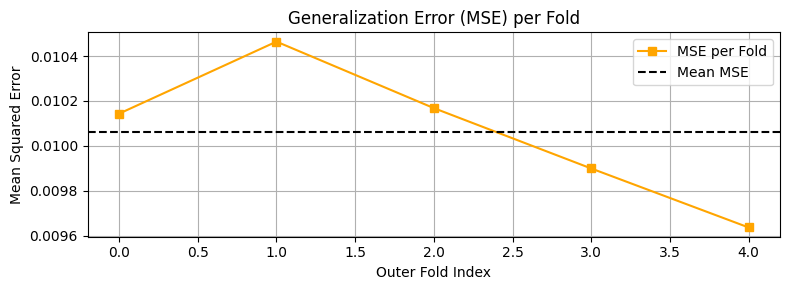

✅ Nested CV Summary:
 → Selected alphas per fold: [100.0, 100.0, 100.0, 100.0, 100.0]
 → Mean Alpha: 100.0000
 → Outer MSEs: [0.010143764292819931, 0.010463959982823607, 0.010168408465688962, 0.009900119446905725, 0.009637917084819312]
 → Avg MSE: 0.010063


In [ ]:
import matplotlib.pyplot as plt

# Plot 1: Selected Alphas
plt.figure(figsize=(8, 3))
plt.plot(best_alphas, marker='o', linestyle='-', label='Selected Alpha')
plt.axhline(np.mean(best_alphas), color='red', linestyle='--', label='Mean Alpha')
plt.xlabel("Outer Fold Index")
plt.ylabel("Alpha (Regularization Strength)")
plt.title("Selected Alpha in Each Outer Fold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Outer Fold MSE
plt.figure(figsize=(8, 3))
plt.plot(outer_mse_scores, marker='s', color='orange', label='MSE per Fold')
plt.axhline(np.mean(outer_mse_scores), color='black', linestyle='--', label='Mean MSE')
plt.xlabel("Outer Fold Index")
plt.ylabel("Mean Squared Error")
plt.title("Generalization Error (MSE) per Fold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Text summary
print("Nested CV Summary:")
print(" → Selected alphas per fold:", best_alphas)
print(" → Mean Alpha: {:.4f}".format(np.mean(best_alphas)))
print(" → Outer MSEs:", outer_mse_scores)
print(" → Avg MSE: {:.6f}".format(np.mean(outer_mse_scores)))
